# Pneumonia Detection from Chest X-Rays — Transfer Learning with ResNet-18

Pneumonia is one of the leading causes of illness and death worldwide, and timely
radiological review is central to treatment decisions. This notebook fine-tunes a
pretrained ResNet-18 to classify pediatric chest X-rays as **NORMAL** or **PNEUMONIA**.

The goal here goes beyond a single accuracy number: the notebook demonstrates a
methodologically sound workflow for a small clinical imaging dataset — correct
train/validation/test separation, a diagnosis of what goes wrong when that separation
is skipped, class-imbalance-aware evaluation, and a Grad-CAM audit of *what the model
is actually looking at* rather than just what it predicts.

**Final result** (held-out test set, n=100, observed once):
**accuracy 0.76 · F1 0.81 · sensitivity 1.00 · specificity 0.52.**
See *Conclusions & Limitations* at the end for what this number does and doesn't mean.

**Contents**
1. Exploratory Data Analysis
2. Transfer Learning Setup
3. Baseline Training *(a deliberately naive first pass, kept for contrast)*
4. Diagnosing the Baseline
5. Fixing the Methodology — validation split & early stopping
6. Final Evaluation
7. Explainability with Grad-CAM
8. Model Persistence

Conclusions & Limitations

## Original Assignment Brief

Pneumonia is one of the leading respiratory illnesses worldwide, and its timely and accurate diagnosis is essential for effective treatment. Manually reviewing chest X-rays is a critical step in this process, and AI can provide valuable support by helping to expedite the assessment. In your role as a consultant data scientist, you will test the ability of a deep learning model to distinguish pneumonia cases from normal images of lungs in chest X-rays.

By fine-tuning a pre-trained convolutional neural network, specifically the ResNet-18 model, your task is to classify X-ray images into two categories: normal lungs and those affected by pneumonia. You can leverage its already trained weights and get an accurate classifier trained faster and with fewer resources.

### The Data

<img src="x-rays_sample.png" align="center"/>
&nbsp

You have a dataset of chest X-rays that have been preprocessed for use with a ResNet-18 model. You can see a sample of 5 images from each category above. Upon unzipping the `chestxrays.zip` file (code provided below), you will find your dataset inside the `data/chestxrays` folder divided into `test` and `train` folders.

There are 150 training images and 50 testing images for each category, NORMAL and PNEUMONIA (300 and 100 in total). For your convenience, this data has already been loaded into a `train_loader` and a `test_loader` using the `DataLoader` class from the PyTorch library.

In [1]:
%matplotlib inline

# Import required libraries
# -------------------------
# Data loading
import random
import numpy as np
from torchvision.transforms import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# Train model
import torch
from torchvision import models
import torch.nn as nn
import torch.optim as optim

# Evaluate model
from torchmetrics import Accuracy, F1Score

# Set random seeds for reproducibility
torch.manual_seed(101010)
np.random.seed(101010)
random.seed(101010)

In [2]:
import os
import zipfile

# Unzip the data folder
if not os.path.exists('data/chestxrays'):
    with zipfile.ZipFile('data/chestxrays.zip', 'r') as zip_ref:
        zip_ref.extractall('data')

In [3]:
# Define the transformations to apply to the images for use with ResNet-18
transform_mean = [0.485, 0.456, 0.406]
transform_std =[0.229, 0.224, 0.225]
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize(mean=transform_mean, std=transform_std)])

# Apply the image transforms
train_dataset = ImageFolder('data/chestxrays/train', transform=transform)
test_dataset = ImageFolder('data/chestxrays/test', transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=len(train_dataset) // 2, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset))

## 1. Exploratory Data Analysis

Before touching the model, we look at the data. In medical imaging, models most often
fail because of the data — artifacts, class imbalance, leakage between splits — not
because of the architecture.

We check three things:
1. **Label mapping** — `ImageFolder` assigns classes alphabetically, so we expect
   `NORMAL=0`, `PNEUMONIA=1`. This needs to be *verified*, not assumed — it determines
   how the sigmoid output is interpreted at evaluation time.
2. **Class balance** — computed from the data, not taken on faith from the task description.
3. **Raw images** — do we see the expected disease signature (whitish consolidation in
   the lung fields)? And do the two classes differ in ways *unrelated* to disease (film
   markers, contrast, framing)? This is the risk of **shortcut learning** — a model can
   learn to recognize the imaging equipment or acquisition protocol instead of the
   pathology itself.

In [4]:
# 1a. Label mapping and class balance
# ------------------------------------
from collections import Counter

# ImageFolder assigns class indices alphabetically
print("Class mapping:", {name: idx for idx, name in enumerate(train_dataset.classes)})

# .targets holds every label in the dataset — we count rather than trust the description
train_counts = Counter(train_dataset.targets)
test_counts = Counter(test_dataset.targets)

for name, idx in train_dataset.class_to_idx.items():
    print(f"{name:10s}  train: {train_counts[idx]:3d}   test: {test_counts[idx]:3d}")

Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}
NORMAL      train: 150   test:  50
PNEUMONIA   train: 150   test:  50


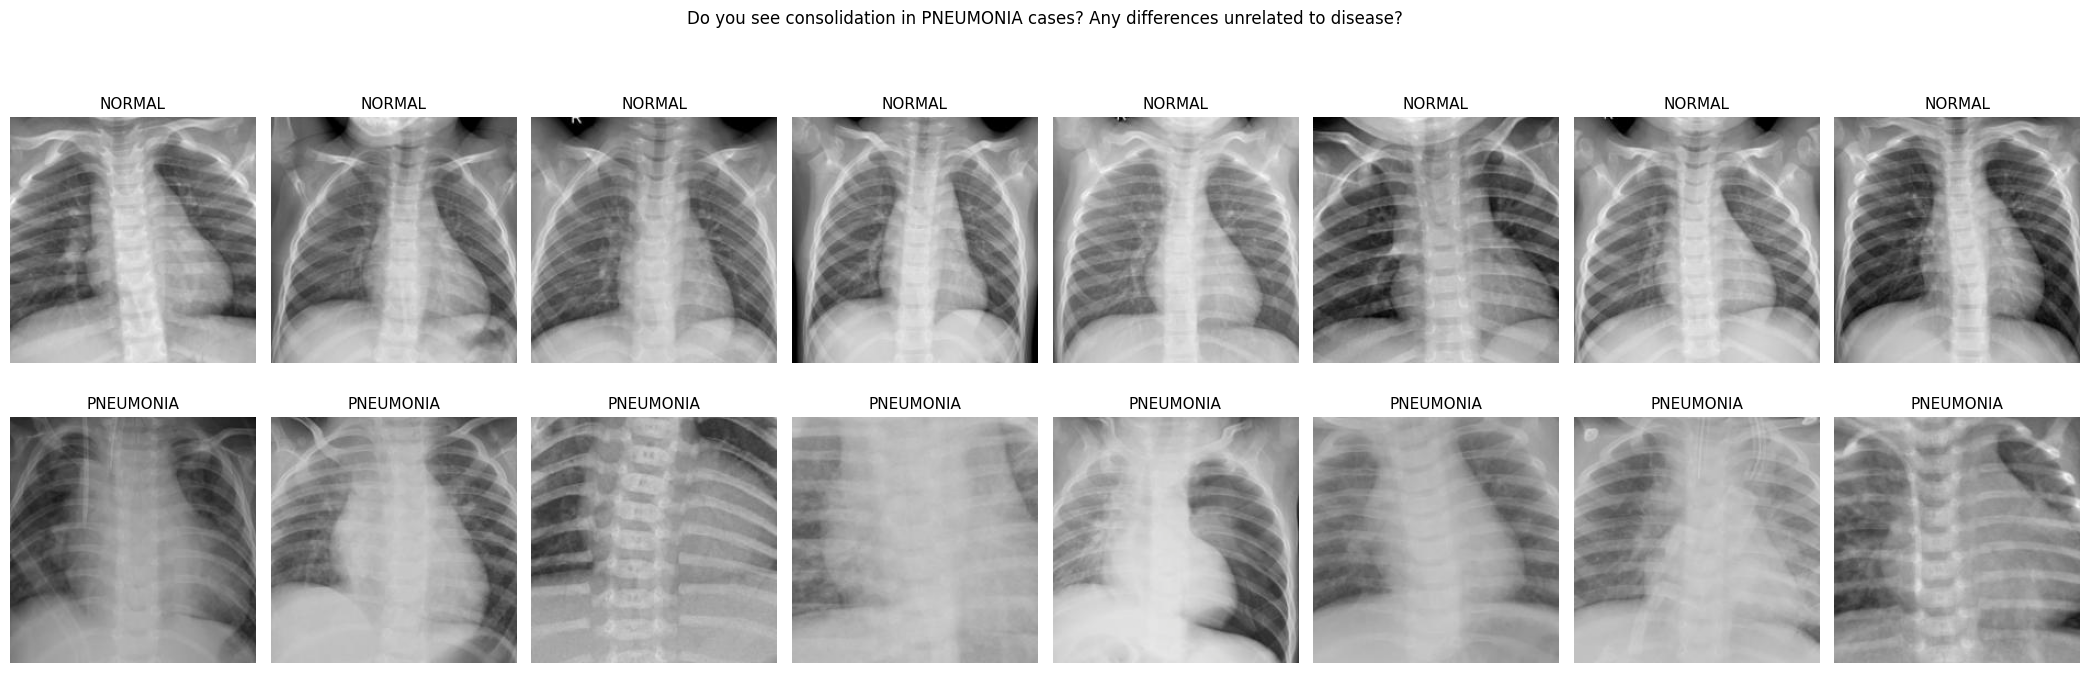

In [5]:
# 1b. Sampling raw images (top row: NORMAL, bottom row: PNEUMONIA)
# ------------------------------------------------------------------
import matplotlib.pyplot as plt

# Tensors are normalized for ImageNet — to see the "real" X-ray we invert it:
# x_norm = (x - mean) / std  =>  x = x_norm * std + mean
mean = torch.tensor(transform_mean).view(3, 1, 1)   # (3,1,1) so it broadcasts across channels
std = torch.tensor(transform_std).view(3, 1, 1)

def denormalize(img):
    return (img * std + mean).clamp(0, 1)

normal_idx = [i for i, t in enumerate(train_dataset.targets) if t == 0][:8]
pneumonia_idx = [i for i, t in enumerate(train_dataset.targets) if t == 1][:8]

fig, axes = plt.subplots(2, 8, figsize=(21, 7))
for ax, idx in zip(axes.flat, normal_idx + pneumonia_idx):
    img, label = train_dataset[idx]                 # (3, 224, 224) — channels first
    img = denormalize(img).permute(1, 2, 0)         # imshow wants (224, 224, 3) — channels last
    ax.imshow(img)
    ax.set_title(train_dataset.classes[label], fontsize=11)
    ax.axis("off")

fig.suptitle("Do you see consolidation in PNEUMONIA cases? Any differences unrelated to disease?", y=1.02)
plt.tight_layout()
plt.show()

## 2. Transfer Learning Setup

ResNet-18 was pretrained on ImageNet: 1.2M natural images, 1000 classes (dogs, cars,
…). Why does that help with X-rays? Because **early CNN layers learn general-purpose
features** — edges, textures, brightness gradients — and only the later layers assemble
those into task-specific concepts. Edges and textures are just as useful on a chest
X-ray as on a photo of a dog. (Empirically, ImageNet features transfer to medical
imaging surprisingly well despite the domain gap — this is a standard starting point in
radiology ML.)

Model surgery:
1. **Freeze the entire backbone** (`requires_grad = False`) — leaves ~11M parameters
   untouched. With only 300 training images, fine-tuning the full network would overfit
   almost immediately: the model would memorize the training set instead of generalizing.
2. **Replace the head**: the original `fc` is `Linear(512 → 1000)` (ImageNet classes).
   We swap in a fresh, trainable `Linear(512 → 1)`.

Why **one output, not two**? For binary classification a single logit is enough:
`sigmoid(logit)` gives the probability of class `1` — PNEUMONIA, per the mapping
confirmed in step 1. Two outputs plus softmax would be mathematically equivalent, but
the provided evaluation code later in this notebook expects the sigmoid formulation, so
the loss function in step 3 is matched to it.

In [6]:
# 2a. Load the pretrained ResNet-18
# -------------------------------------
# Pretrained weights download to TORCH_HOME — pointed at ./models (mounted from the
# host) so they survive container restarts instead of re-downloading every time
os.environ["TORCH_HOME"] = "models"

resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

total_params = sum(p.numel() for p in resnet18.parameters())
print(f"Total parameters: {total_params:,}")
print("Original head:", resnet18.fc)  # Linear(512 -> 1000 ImageNet classes)

Total parameters: 11,689,512
Original head: Linear(in_features=512, out_features=1000, bias=True)


In [7]:
# 2b. Freeze the backbone, replace the head
# --------------------------------------------
for param in resnet18.parameters():
    param.requires_grad = False

# The new layer has requires_grad=True by default — it's the only thing we'll train.
# in_features is read off the model rather than hardcoded as 512
resnet18.fc = nn.Linear(resnet18.fc.in_features, 1)

trainable_names = [name for name, p in resnet18.named_parameters() if p.requires_grad]
trainable_params = sum(p.numel() for p in resnet18.parameters() if p.requires_grad)
print(f"Trainable tensors: {trainable_names}")
print(f"Trainable parameters: {trainable_params:,} of {total_params:,} "
      f"({100 * trainable_params / total_params:.3f}%)")

# Shape sanity check: a batch of 2 images should produce 2 logits
with torch.no_grad():
    dummy_out = resnet18(torch.randn(2, 3, 224, 224))
print("Output shape for a batch of 2:", tuple(dummy_out.shape))

Trainable tensors: ['fc.weight', 'fc.bias']
Trainable parameters: 513 of 11,689,512 (0.004%)
Output shape for a batch of 2: (2, 1)


## 3. Baseline Training (a deliberately naive first pass)

This first attempt is kept in the notebook on purpose — it illustrates two very common
training pitfalls, and the *diagnosis* in the next section is exactly how you catch
them in practice.

Components:
- **Loss:** `BCEWithLogitsLoss` — takes raw logits and applies a numerically stable
  sigmoid internally. (Sigmoid saturates: a logit of -40 rounds to `0.0` in float32, so
  `log(0) = -inf` and training explodes with NaNs unless the sigmoid and the log are
  fused into one stable expression. Rule of thumb: *apply sigmoid/softmax only for
  interpretation, never before the loss.*)
- **Optimizer:** Adam, restricted to the head's parameters (`resnet18.fc.parameters()`)
  — the frozen backbone has no gradients anyway, but the explicit restriction is a
  readable statement of intent and a safety net.
- **Labels:** the loader yields `int64` of shape `(batch,)`; the loss expects `float32`
  of shape `(batch, 1)`, matching the model's output → `labels.float().unsqueeze(1)`.

The anatomy of one training step (worth knowing by heart):
1. `optimizer.zero_grad()` — clear gradients from the previous step (PyTorch
   *accumulates* them by default),
2. forward pass — compute predictions and loss,
3. `loss.backward()` — compute gradients via autograd,
4. `optimizer.step()` — update the weights.

**What's naive here:** `train_loader` uses `batch_size = len(train_dataset) // 2`, i.e.
two giant batches per epoch — only **2 gradient updates per epoch**. Combined with a
relatively high learning rate (0.01), this starves the 513-parameter head of the many
small corrective steps it needs. There is also no validation set yet, so there is no
honest way to tell *when* to stop.

In [8]:
# 3. Training the classification head (baseline)
# --------------------------------------------------
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(resnet18.fc.parameters(), lr=0.01)

num_epochs = 15

for epoch in range(num_epochs):
    resnet18.train()
    epoch_loss = 0.0
    epoch_correct = 0

    for inputs, labels in train_loader:
        labels = labels.float().unsqueeze(1)   # int64 (batch,) -> float32 (batch, 1)

        optimizer.zero_grad()                  # 1. clear stale gradients
        outputs = resnet18(inputs)             # 2. forward: logits (batch, 1)
        loss = criterion(outputs, labels)      #    loss on raw logits
        loss.backward()                        # 3. compute gradients
        optimizer.step()                       # 4. update the head's weights

        # Bookkeeping (outside the computation graph, hence .item()/.detach())
        epoch_loss += loss.item() * inputs.size(0)
        preds = (torch.sigmoid(outputs.detach()) > 0.5).float()
        epoch_correct += (preds == labels).sum().item()

    n = len(train_dataset)
    print(f"Epoch {epoch + 1}/{num_epochs}  "
          f"loss: {epoch_loss / n:.4f}  "
          f"train acc: {epoch_correct / n:.3f}")

Epoch 1/15  loss: 1.0363  train acc: 0.537


Epoch 2/15  loss: 0.7455  train acc: 0.563


Epoch 3/15  loss: 0.6838  train acc: 0.617


Epoch 4/15  loss: 0.4519  train acc: 0.777


Epoch 5/15  loss: 0.4842  train acc: 0.753


...

Epoch 11/15  loss: 0.2468  train acc: 0.903


Epoch 12/15  loss: 0.2166  train acc: 0.913


Epoch 13/15  loss: 0.2226  train acc: 0.910


Epoch 14/15  loss: 0.2172  train acc: 0.903


Epoch 15/15  loss: 0.2025  train acc: 0.910


### Evaluating the baseline model (provided evaluation code)

Run below to score the current model on the test set. The code in this cell is
provided as-is by the assignment.

In [9]:
#-------------------
# Evaluate the model
#-------------------

# Set model to evaluation mode
model = resnet18
model.eval()

# Initialize metrics for accuracy and F1 score
accuracy_metric = Accuracy(task="binary")
f1_metric = F1Score(task="binary")

# Create lists store all predictions and labels
all_preds = []
all_labels = []

# Disable gradient calculation for evaluation
with torch.no_grad():
  for inputs, labels in test_loader:
    # Forward pass
    outputs = model(inputs)
    preds = torch.sigmoid(outputs).round()  # Round to 0 or 1

    # Extend the lists with predictions and labels
    all_preds.extend(preds.tolist())
    all_labels.extend(labels.unsqueeze(1).tolist())

    # Convert lists back to tensors
    all_preds = torch.tensor(all_preds)
    all_labels = torch.tensor(all_labels)

    # Calculate accuracy and F1 score
    test_acc = accuracy_metric(all_preds, all_labels).item()
    test_f1 = f1_metric(all_preds, all_labels).item()

## 4. Diagnosing the Baseline

Accuracy and F1 are aggregate numbers — in medicine we need to know precisely **what
kind of mistakes** the model makes and **which ones matter**. We break the result down
into a confusion matrix:

|                       | pred: NORMAL | pred: PNEUMONIA |
|-----------------------|--------------|------------------|
| **actual: NORMAL**    | TN           | FP (false alarm) |
| **actual: PNEUMONIA** | **FN (missed case!)** | TP |

From it we derive the pair of metrics diagnostics actually cares about:
- **Sensitivity** (recall) = TP / (TP + FN) — *what fraction of sick patients did we
  catch*. Low sensitivity means missed pneumonia cases — the most dangerous failure
  mode in a screening tool.
- **Specificity** = TN / (TN + FP) — *what fraction of healthy patients did we
  correctly reassure*. Low specificity means false alarms and unnecessary follow-up.

Why can F1 be much lower than accuracy? F1 only looks at the positive class
(PNEUMONIA): if the model "plays it safe" and leans toward predicting NORMAL, accuracy
can still look decent (healthy patients are classified fine), while sensitivity — and
F1 with it — collapses.

In [10]:
# 4. Confusion-matrix helper, applied to the baseline
# -----------------------------------------------------
def confusion_report(preds, labels, acc, f1):
    """Prints a confusion matrix and derived clinical metrics for binary predictions."""
    tp = ((preds == 1) & (labels == 1)).sum().item()
    tn = ((preds == 0) & (labels == 0)).sum().item()
    fp = ((preds == 1) & (labels == 0)).sum().item()
    fn = ((preds == 0) & (labels == 1)).sum().item()

    sensitivity = tp / (tp + fn) if tp + fn else float("nan")
    specificity = tn / (tn + fp) if tn + fp else float("nan")
    precision = tp / (tp + fp) if tp + fp else float("nan")

    print(f"Accuracy: {acc:.3f}   F1: {f1:.3f}\n")
    print("                    pred NORMAL   pred PNEUMONIA")
    print(f"actual NORMAL:         TN={tn:3d}          FP={fp:3d}")
    print(f"actual PNEUMONIA:      FN={fn:3d}          TP={tp:3d}\n")
    print(f"Sensitivity (recall): {sensitivity:.3f}  <- fraction of sick patients detected")
    print(f"Specificity:          {specificity:.3f}  <- fraction of healthy patients correctly cleared")
    print(f"Precision:            {precision:.3f}  <- fraction of alarms that were correct")
    print(f"\nMissed cases (FN): {fn} of {tp + fn} pneumonia patients")
    return dict(tp=tp, tn=tn, fp=fp, fn=fn,
                sensitivity=sensitivity, specificity=specificity, precision=precision)

baseline_report = confusion_report(all_preds, all_labels, test_acc, test_f1)

Accuracy: 0.610   F1: 0.719

                    pred NORMAL   pred PNEUMONIA
actual NORMAL:         TN= 11          FP= 39
actual PNEUMONIA:      FN=  0          TP= 50

Sensitivity (recall): 1.000  <- fraction of sick patients detected
Specificity:          0.220  <- fraction of healthy patients correctly cleared
Precision:            0.562  <- fraction of alarms that were correct

Missed cases (FN): 0 of 50 pneumonia patients


## 5. Fixing the Methodology

The baseline above is unstable — small hyperparameter changes during development swung
sensitivity anywhere between 0.38 and 1.00, with specificity moving in the opposite
direction. Two causes: (a) only 2 gradient steps per epoch at batch size 150, (b) a
learning rate (0.01) that lets the 513-parameter head overshoot instead of settling. A
third, easy-to-miss problem is methodological: **deciding how many epochs to train by
looking at test-set performance is a form of data leakage** — the test set stops
measuring generalization the moment it starts influencing decisions. It should be
observed **once, at the very end**.

We fix all three:
1. **Validation split** — carve 20% off the training set, **stratified** (equal
   proportion per class) so the 60 held-out images mirror the 50/50 class balance of the
   full set. Model-selection decisions (epochs, learning rate, batch size, decision
   threshold) are made against this split; the test set stays untouched until the final
   evaluation.
2. **Smaller batches (8)** — 240⁄8 = 30 gradient steps per epoch instead of 2.
3. **Lower learning rate (0.001)** — smoother convergence, less oscillation.
4. **Checkpointing the best epoch** — track validation loss after every epoch and keep
   the weights from its minimum (a simple form of early stopping), rather than whatever
   the training loop happens to end on.

What to watch for in the printed log: training and validation loss should fall
*together*. When training loss keeps dropping while validation loss turns back up,
that's the textbook signature of **overfitting** — further epochs are memorizing, not
generalizing.

In [11]:
# 5a. Stratified train -> train/val split, new data loaders
# -------------------------------------------------------------
from torch.utils.data import Subset

val_fraction = 0.2
rng = np.random.default_rng(101010)   # a dedicated generator — doesn't touch the global seeds

train_idx, val_idx = [], []
for cls in (0, 1):
    cls_idx = [i for i, t in enumerate(train_dataset.targets) if t == cls]
    cls_idx = rng.permutation(cls_idx)                # shuffle within the class
    n_val = int(len(cls_idx) * val_fraction)
    val_idx.extend(cls_idx[:n_val])                   # 30 per class go to validation
    train_idx.extend(cls_idx[n_val:])                 # the rest stay in training

train_subset = Subset(train_dataset, train_idx)
val_subset = Subset(train_dataset, val_idx)

# Smaller batches -> more gradient steps per epoch
train_loader_s = DataLoader(train_subset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64)

print(f"train: {len(train_subset)}  val: {len(val_subset)}  "
      f"(gradient steps/epoch: {len(train_loader_s)})")

train: 240  val: 60  (gradient steps/epoch: 30)


In [12]:
# 5b. Training from scratch with validation monitoring and best-epoch checkpointing
# --------------------------------------------------------------------------------
import copy

def make_model():
    '''A fresh frozen ResNet-18 with a new head — every experiment starts from a clean slate.'''
    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for p in m.parameters():
        p.requires_grad = False
    m.fc = nn.Linear(m.fc.in_features, 1)
    return m

def evaluate_loss(m, loader):
    '''Mean loss and accuracy on a given loader (no gradient tracking).'''
    m.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            labels = labels.float().unsqueeze(1)
            outputs = m(inputs)
            total_loss += criterion(outputs, labels).item() * inputs.size(0)
            correct += ((torch.sigmoid(outputs) > 0.5).float() == labels).sum().item()
            n += inputs.size(0)
    return total_loss / n, correct / n

resnet18 = make_model()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(resnet18.fc.parameters(), lr=0.001)

num_epochs = 25
best_val_loss = float("inf")
best_state = None
best_epoch = -1

for epoch in range(num_epochs):
    resnet18.train()
    for inputs, labels in train_loader_s:
        labels = labels.float().unsqueeze(1)
        optimizer.zero_grad()
        loss = criterion(resnet18(inputs), labels)
        loss.backward()
        optimizer.step()

    train_loss, train_acc = evaluate_loss(resnet18, train_loader_s)
    val_loss, val_acc = evaluate_loss(resnet18, val_loader)

    marker = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(resnet18.state_dict())
        best_epoch = epoch + 1
        marker = "  <- best so far"

    print(f"Epoch {epoch + 1:2d}/{num_epochs}  "
          f"train: {train_loss:.4f} (acc {train_acc:.3f})  "
          f"val: {val_loss:.4f} (acc {val_acc:.3f}){marker}")

resnet18.load_state_dict(best_state)
torch.save(best_state, "models/resnet18_pneumonia_head.pt")
print(f"\nRestored weights from epoch {best_epoch} (val loss {best_val_loss:.4f}); "
      f"saved to models/resnet18_pneumonia_head.pt")

Epoch  1/25  train: 0.7799 (acc 0.500)  val: 0.7982 (acc 0.517)  <- best so far


Epoch  2/25  train: 0.4643 (acc 0.796)  val: 0.5059 (acc 0.733)  <- best so far


Epoch  3/25  train: 0.3300 (acc 0.883)  val: 0.4115 (acc 0.800)  <- best so far


Epoch  4/25  train: 0.3121 (acc 0.896)  val: 0.3935 (acc 0.883)  <- best so far


Epoch  5/25  train: 0.2713 (acc 0.917)  val: 0.3647 (acc 0.917)  <- best so far


...

Epoch 22/25  train: 0.1413 (acc 0.950)  val: 0.3123 (acc 0.867)  <- best so far


Epoch 23/25  train: 0.1398 (acc 0.958)  val: 0.3175 (acc 0.867)


Epoch 24/25  train: 0.1507 (acc 0.954)  val: 0.3391 (acc 0.900)


Epoch 25/25  train: 0.1478 (acc 0.958)  val: 0.3209 (acc 0.867)



Restored weights from epoch 22 (val loss 0.3123); saved to models/resnet18_pneumonia_head.pt


## 6. Final Evaluation (test set, observed once)

This is the only other point in the notebook where the test set is used. The same
provided evaluation cell from step 3 is re-run — now against the model selected by
validation in step 5 — followed by the same confusion-matrix breakdown. These are the
numbers actually reported.

In [13]:
#-------------------
# Evaluate the model
#-------------------

# Set model to evaluation mode
model = resnet18
model.eval()

# Initialize metrics for accuracy and F1 score
accuracy_metric = Accuracy(task="binary")
f1_metric = F1Score(task="binary")

# Create lists store all predictions and labels
all_preds = []
all_labels = []

# Disable gradient calculation for evaluation
with torch.no_grad():
  for inputs, labels in test_loader:
    # Forward pass
    outputs = model(inputs)
    preds = torch.sigmoid(outputs).round()  # Round to 0 or 1

    # Extend the lists with predictions and labels
    all_preds.extend(preds.tolist())
    all_labels.extend(labels.unsqueeze(1).tolist())

    # Convert lists back to tensors
    all_preds = torch.tensor(all_preds)
    all_labels = torch.tensor(all_labels)

    # Calculate accuracy and F1 score
    test_acc = accuracy_metric(all_preds, all_labels).item()
    test_f1 = f1_metric(all_preds, all_labels).item()

In [14]:
# Final confusion matrix — the validated model, test set observed once
final_report = confusion_report(all_preds, all_labels, test_acc, test_f1)

Accuracy: 0.760   F1: 0.806

                    pred NORMAL   pred PNEUMONIA
actual NORMAL:         TN= 26          FP= 24
actual PNEUMONIA:      FN=  0          TP= 50

Sensitivity (recall): 1.000  <- fraction of sick patients detected
Specificity:          0.520  <- fraction of healthy patients correctly cleared
Precision:            0.676  <- fraction of alarms that were correct

Missed cases (FN): 0 of 50 pneumonia patients


## 7. Explainability with Grad-CAM

"The model says PNEUMONIA" isn't enough in a clinical context — the natural follow-up
is *based on what evidence?* Grad-CAM (Gradient-weighted Class Activation Mapping)
answers with a heatmap overlaid on the image: which regions pushed the prediction most
strongly toward a given class.

The intuition:
1. Take the activations of the **last convolutional block** (`layer4` → 512 feature
   maps, 7×7) — the last point in the network where the representation still has
   spatial structure.
2. Compute the **gradient of the logit with respect to those activations**: "if this
   feature map were stronger, how much would the PNEUMONIA score increase?" Averaging
   the gradient spatially gives one importance weight per feature map.
3. Sum the maps weighted by those importances, clip negative values with ReLU (keep
   only what *supports* the class), and upsample from 7×7 to 224×224.

Two implementation details worth remembering:
- The backbone is frozen (`requires_grad=False`), so autograd normally **won't**
  compute gradients with respect to `layer4`'s activations — nothing downstream needs
  them. The fix: enable gradients on the *input image* itself, which pulls every
  intermediate activation back into the backward graph.
- Activations and gradients are captured with **hooks**
  (`register_forward_hook` / `register_full_backward_hook`) — a general-purpose
  technique for inspecting the internals of any `nn.Module`.

How to read the maps: heat over the lung fields is reassuring; heat concentrated on
image borders, film markers, shoulders, or the diaphragm raises the shortcut-learning
concern from step 1. And a note of interpretive humility: the underlying resolution is
a mere 7×7, and Grad-CAM is **circumstantial evidence, not proof** — it shows what
correlates with the decision, not what caused it.

In [15]:
# 7a. Grad-CAM implementation (from scratch, using hooks — no external libraries)
# ---------------------------------------------------------------------------------
import torch.nn.functional as F

_saved = {}

def _forward_hook(module, args, output):
    _saved["act"] = output                    # layer4 activations: (1, 512, 7, 7)

def _backward_hook(module, grad_input, grad_output):
    _saved["grad"] = grad_output[0]           # gradient of the logit w.r.t. activations

def grad_cam(model, img):
    '''Returns (224x224 heatmap in [0,1], PNEUMONIA probability) for a single image.'''
    model.eval()
    h_fwd = model.layer4.register_forward_hook(_forward_hook)
    h_bwd = model.layer4.register_full_backward_hook(_backward_hook)
    try:
        x = img.unsqueeze(0).clone().requires_grad_(True)  # gradient on the input revives backward
        logit = model(x)                                   # (1, 1)
        model.zero_grad()
        logit.backward()

        act = _saved["act"].squeeze(0)                     # (512, 7, 7)
        grad = _saved["grad"].squeeze(0)                   # (512, 7, 7)
        weights = grad.mean(dim=(1, 2))                    # importance of each map: (512,)
        cam = torch.relu((weights[:, None, None] * act).sum(dim=0))  # (7, 7)

        cam = F.interpolate(cam[None, None], size=(224, 224),
                            mode="bilinear", align_corners=False).squeeze()
        if cam.max() > 0:
            cam = cam / cam.max()                          # scale to [0, 1] for plotting
        return cam.detach(), torch.sigmoid(logit).item()
    finally:
        h_fwd.remove()                                     # always clean up hooks —
        h_bwd.remove()                                     # otherwise they stay attached forever

print("grad_cam ready")

grad_cam ready


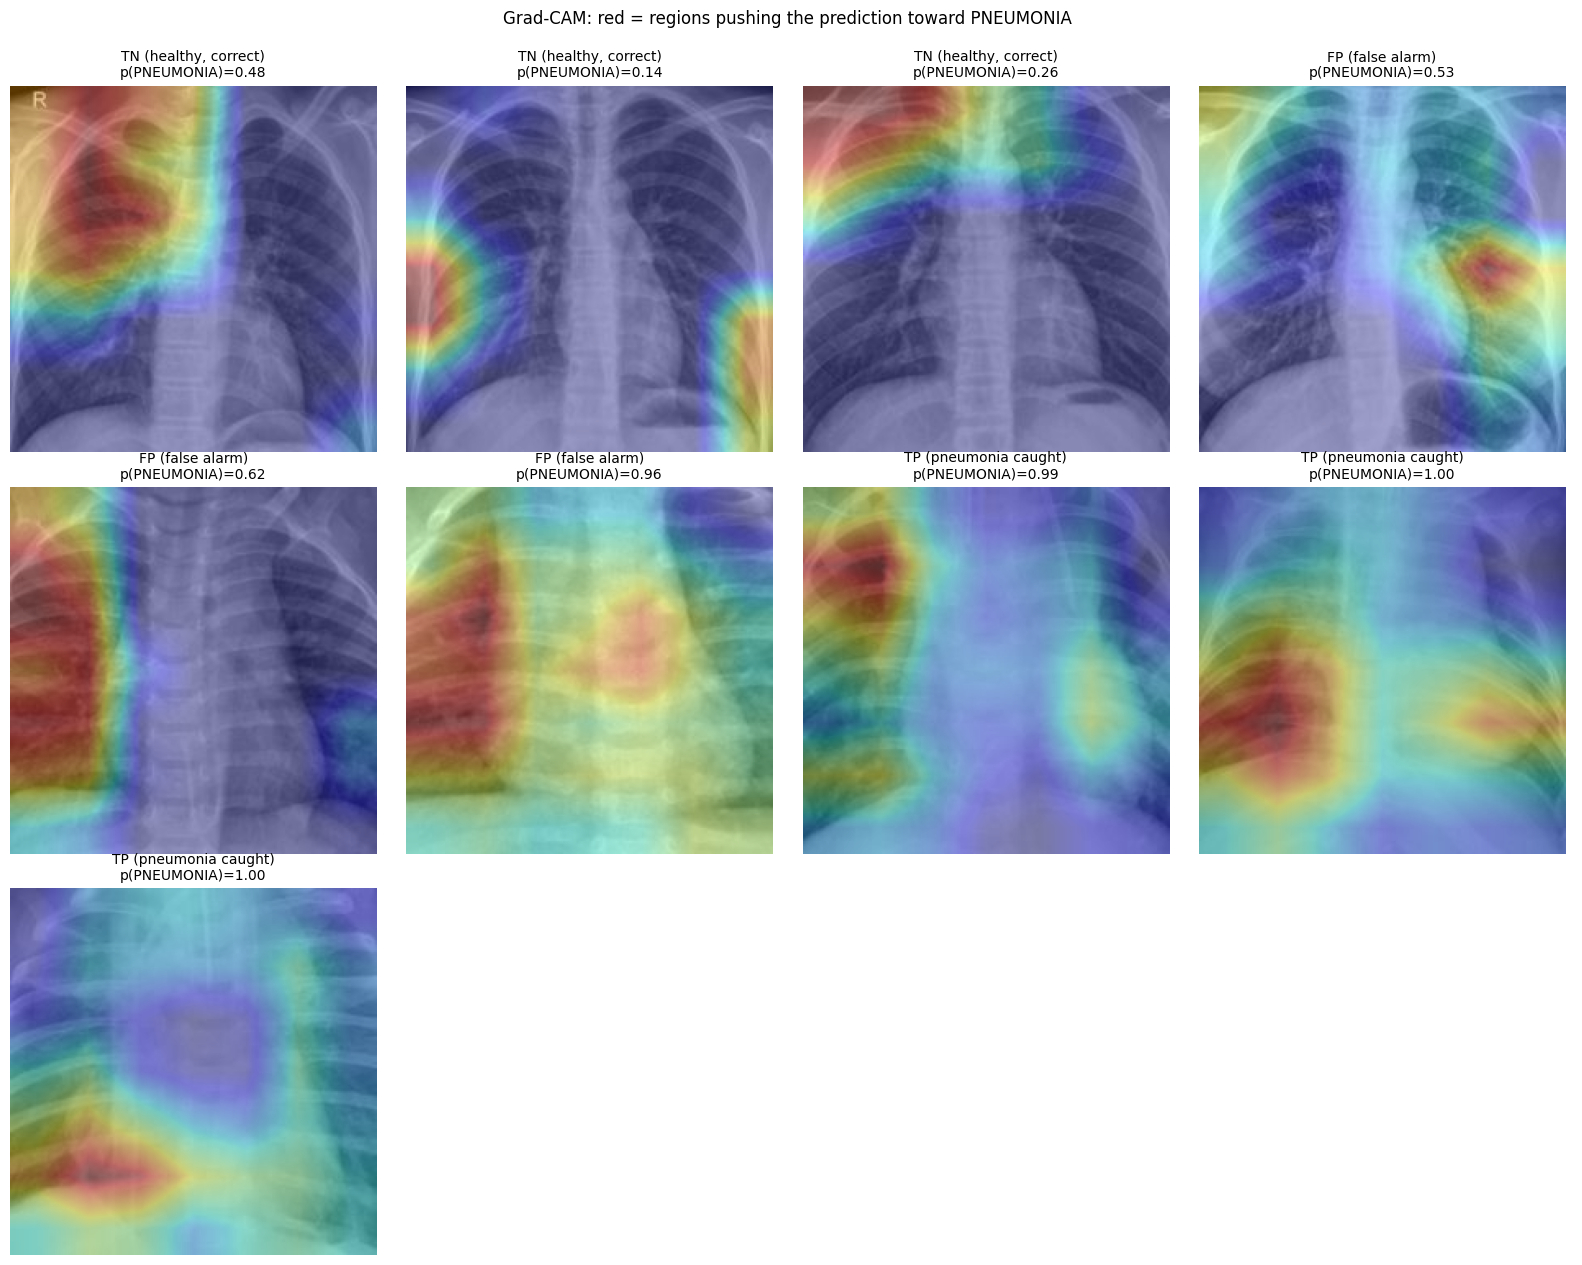

In [16]:
# 7b. Heatmaps for representative cases: hits, misses, and false alarms
# --------------------------------------------------------------------------
# test_loader yields a single, unshuffled batch, so indices into all_preds/all_labels
# line up directly with indices into test_dataset
pred_flat = all_preds.squeeze(1).int()
label_flat = all_labels.squeeze(1).int()

cases = {
    "TN (healthy, correct)":  [i for i in range(len(label_flat)) if label_flat[i] == 0 and pred_flat[i] == 0],
    "FP (false alarm)":       [i for i in range(len(label_flat)) if label_flat[i] == 0 and pred_flat[i] == 1],
    "TP (pneumonia caught)":  [i for i in range(len(label_flat)) if label_flat[i] == 1 and pred_flat[i] == 1],
    "FN (missed!)":           [i for i in range(len(label_flat)) if label_flat[i] == 1 and pred_flat[i] == 0],
}

selection = [(name, i) for name, idxs in cases.items() for i in idxs[:3]]

n_cols = 4
n_rows = -(-len(selection) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4.2 * n_rows))
for ax, (name, idx) in zip(axes.flat, selection):
    img, label = test_dataset[idx]
    cam, p = grad_cam(resnet18, img)

    ax.imshow(denormalize(img).permute(1, 2, 0))
    ax.imshow(cam, cmap="jet", alpha=0.35)          # heatmap overlay
    ax.set_title(f"{name}\np(PNEUMONIA)={p:.2f}", fontsize=10)
    ax.axis("off")

for ax in axes.flat[len(selection):]:
    ax.axis("off")

fig.suptitle("Grad-CAM: red = regions pushing the prediction toward PNEUMONIA", y=1.0)
plt.tight_layout()
plt.show()

## 8. Model Persistence

`resnet18.state_dict()` on the full model captures **every** tensor — 11.7M parameters
× 4 bytes (float32) ≈ 45 MB — including the frozen backbone, which anyone can
reconstruct from torchvision. Saving only the head (`resnet18.fc.state_dict()`, 513
parameters) drops that to about 2 KB — a 20,000× reduction carrying the same trainable
information.

**There's a catch.** During training in `.train()` mode, the backbone's BatchNorm
layers kept updating their *running statistics* (mean/variance) from our X-rays, even
though `requires_grad=False` — gradient-freezing and statistic-freezing are two
different things. Those running statistics live in the backbone's `state_dict()`, not
the head's. So:
- the full checkpoint reproduces exactly the model that was evaluated,
- a fresh `make_model()` plus the head-only checkpoint reproduces a backbone with
  BatchNorm statistics from **ImageNet**, not from our data — predictions shift
  slightly.

The cell below measures that shift on the **validation set** (the test set has already
been spent, once, in step 6). The takeaway: a model's "state" is not only its trainable
weights — anything that influences the forward pass counts.

In [17]:
# 8. Saving the head only, and measuring the BatchNorm gap
# -------------------------------------------------------------
torch.save(resnet18.fc.state_dict(), "models/pneumonia_head_only.pt")

for fname in ("resnet18_pneumonia_head.pt", "pneumonia_head_only.pt"):
    size = os.path.getsize(os.path.join("models", fname))
    print(f"models/{fname}: {size / 1e6:8.3f} MB")

# Reconstruction "from the head alone": fresh backbone (ImageNet BN stats) + our head
reconstructed = make_model()
reconstructed.fc.load_state_dict(torch.load("models/pneumonia_head_only.pt"))

full_loss, full_acc = evaluate_loss(resnet18, val_loader)       # original (BN fit to our data)
rec_loss, rec_acc = evaluate_loss(reconstructed, val_loader)    # reconstruction (BN from ImageNet)

print(f"\nValidation — full checkpoint:   loss {full_loss:.4f}, acc {full_acc:.3f}")
print(f"Validation — head-only reload:  loss {rec_loss:.4f}, acc {rec_acc:.3f}")
print("\nThe gap is entirely due to BatchNorm running statistics — model state that lives outside fc.")

models/resnet18_pneumonia_head.pt:   44.787 MB
models/pneumonia_head_only.pt:    0.004 MB



Validation — full checkpoint:   loss 0.3123, acc 0.867
Validation — head-only reload:  loss 0.5528, acc 0.783

The gap is entirely due to BatchNorm running statistics — model state that lives outside fc.


## Conclusions & Limitations

**Result:** fine-tuning the head of a frozen ResNet-18 (513 trainable parameters) on
240 pediatric chest X-rays, with the training epoch selected by validation loss (early
stopping, best epoch 22/25). On a held-out test set (n=100, class-balanced), observed
**once**: **accuracy 0.76, F1 0.81, sensitivity 1.00, specificity 0.52.** This profile
matches a screening tool: zero missed pneumonia cases, at the cost of 24 false alarms
out of 50 healthy patients.

**Limitations** (a section every clinical ML write-up needs):
1. **Internal validation only.** The test set is drawn from the same distribution as
   training — one hospital, a pediatric (1–5 year old) population. No external
   validation has been performed; performance on data from a different site or scanner
   will very likely be lower.
2. **Suspected shortcut learning.** The Grad-CAM audit in step 7 shows false positives
   correlating with tight image cropping, and this dataset is documented to differ in
   acquisition protocol between classes (sicker patients imaged differently from
   routine controls). The model is partly classifying *how the image was taken*, not
   only the underlying pathology.
3. **Small sample, and CPU floating-point non-determinism.** n=100 in the test set
   gives a 95% CI for accuracy of roughly ±0.08. This is not just theoretical: re-running
   this exact notebook (same code, same fixed seeds) produced accuracy 0.80 in one
   execution and 0.76 in another, purely from non-deterministic multi-threaded
   convolution ops on CPU compounding over 750 gradient steps. Differences between
   training configurations explored during development were within this same noise band.
4. **Specificity of ~0.5 is not acceptable for autonomous use** — the model could serve
   only as a first-pass filter, with every positive call reviewed by a radiologist.

**Natural next steps:** external validation on a dataset from a different institution,
standardized preprocessing (e.g. lung-field segmentation to remove crop-dependent
cues), data augmentation (random crop/rotation), unfreezing `layer4` with a small
learning rate for deeper fine-tuning, and threshold calibration on the validation set
for a target sensitivity.